# Hawk/Dove Label Metric Comparison — Flat-Size Intraday Backtest

Compares four JPM NLP score metrics for classifying speakers as hawk/dove:
- `hawk_dove_score` — raw per-speech score (most reactive, noisiest)
- `trailing_5_avg` — trailing 5-speech average (current default)
- `rolling_6m_avg` — 6-month rolling average
- `cb_3m_trailing_avg` — 3-month committee-breadth trailing average

All backtests use **flat sizing** (1× BASE\_BPV per trade), same direction thresholds (±10),
same entry/exit offsets (T-45min / T+180min), same contract (IMM\_3×IMM\_4).
P&L reported in **basis points**.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"C:\Users\chris\clee\ARBS")

import datetime
import pytz
import re
import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
plt.style.use("ggplot")
params = {
    "legend.fontsize": "large",
    "figure.figsize": (14, 8),
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "xtick.labelsize": "large",
    "ytick.labelsize": "large",
}
pylab.rcParams.update(params)

import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")

ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET = datetime.timedelta(minutes=180)
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
HAWK_THRESHOLD = 10
DOVE_THRESHOLD = -10
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH = datetime.time(17, 0)
BLACKOUT_BD = 1
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END = "2026-06-24"

SCORE_METRICS = ["hawk_dove_score", "trailing_5_avg", "rolling_6m_avg", "cb_3m_trailing_avg"]
METRIC_LABELS = {
    "hawk_dove_score": "Raw per-speech",
    "trailing_5_avg": "Trailing 5-speech",
    "rolling_6m_avg": "Rolling 6-month",
    "cb_3m_trailing_avg": "CB 3-month trailing",
}
METRIC_COLORS = {
    "hawk_dove_score": "#e74c3c",
    "trailing_5_avg": "#2980b9",
    "rolling_6m_avg": "#27ae60",
    "cb_3m_trailing_avg": "#8e44ad",
}

print("Config loaded.")

Config loaded.


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme

fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(
    BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS],
    show_tqdm=True, bulk_chunk_weeks=52,
)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm_scores = pd.read_csv(
    r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv"
)
jpm_scores["date"] = pd.to_datetime(jpm_scores["date"]).dt.date
jpm_scores = jpm_scores.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN_SPEAKERS = sorted(jpm_scores["speaker"].unique())
print(f"JPM speakers: {len(KNOWN_SPEAKERS)}")

# Show score ranges per metric
for m in SCORE_METRICS:
    print(f"  {m:25s} range=[{jpm_scores[m].min():.0f}, {jpm_scores[m].max():.0f}]")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1477
JPM speakers: 23
  hawk_dove_score           range=[-63, 54]
  trailing_5_avg            range=[-34, 55]
  rolling_6m_avg            range=[-53, 54]
  cb_3m_trailing_avg        range=[-42, 33]


## 2. Backtest Engine

In [3]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

FOMC_DATES = [
    datetime.date(2020, 1, 29), datetime.date(2020, 3, 15), datetime.date(2020, 4, 29),
    datetime.date(2020, 6, 10), datetime.date(2020, 7, 29), datetime.date(2020, 9, 16),
    datetime.date(2020, 11, 5), datetime.date(2020, 12, 16),
    datetime.date(2021, 1, 27), datetime.date(2021, 3, 17), datetime.date(2021, 4, 28),
    datetime.date(2021, 6, 16), datetime.date(2021, 7, 28), datetime.date(2021, 9, 22),
    datetime.date(2021, 11, 3), datetime.date(2021, 12, 15),
    datetime.date(2022, 1, 26), datetime.date(2022, 3, 16), datetime.date(2022, 5, 4),
    datetime.date(2022, 6, 15), datetime.date(2022, 7, 27), datetime.date(2022, 9, 21),
    datetime.date(2022, 11, 2), datetime.date(2022, 12, 14),
    datetime.date(2023, 2, 1), datetime.date(2023, 3, 22), datetime.date(2023, 5, 3),
    datetime.date(2023, 6, 14), datetime.date(2023, 7, 26), datetime.date(2023, 9, 20),
    datetime.date(2023, 11, 1), datetime.date(2023, 12, 13),
    datetime.date(2024, 1, 31), datetime.date(2024, 3, 20), datetime.date(2024, 5, 1),
    datetime.date(2024, 6, 12), datetime.date(2024, 7, 31), datetime.date(2024, 9, 18),
    datetime.date(2024, 11, 7), datetime.date(2024, 12, 18),
    datetime.date(2025, 1, 29), datetime.date(2025, 3, 19), datetime.date(2025, 5, 7),
    datetime.date(2025, 6, 18), datetime.date(2025, 7, 30), datetime.date(2025, 9, 17),
    datetime.date(2025, 10, 29), datetime.date(2025, 12, 10),
    datetime.date(2026, 1, 28), datetime.date(2026, 3, 18), datetime.date(2026, 4, 29),
    datetime.date(2026, 6, 17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)


def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    parts = cleaned.split()
    return parts[-1] if parts else ""


def is_in_blackout(event_date):
    for fomc in FOMC_DATES:
        s = ql.Date(fomc.day, fomc.month, fomc.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date
                <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False


def cap_exit(exit_ts, entry_ts):
    exit_ql = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(exit_ql):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts


def build_score_cache(metric):
    cache = {}
    for speaker, grp in jpm_scores.groupby("speaker"):
        g = grp.sort_values("date")
        cache[speaker] = (g["date"].values, g[metric].values)
    return cache


def get_score(cache, speaker, as_of):
    if speaker not in cache:
        return np.nan
    dates, scores = cache[speaker]
    mask = dates < np.datetime64(as_of)
    if not mask.any():
        return np.nan
    return float(scores[mask][-1])


def score_to_direction(score):
    if pd.isna(score):
        return 0
    if score >= HAWK_THRESHOLD:
        return 1
    if score <= DOVE_THRESHOLD:
        return -1
    return 0


def build_events(metric):
    cache = build_score_cache(metric)
    events = []
    for _, row in fed_speak_df.iterrows():
        speaker = extract_speaker(row["Title"])
        if speaker not in KNOWN_SPEAKERS:
            continue
        ts = row["TimestampNYC"]
        if pd.isna(ts):
            continue
        if ts.tzinfo is None:
            ts = NYC_tz.localize(ts)
        if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH:
            continue
        if is_in_blackout(ts.date()):
            continue
        if "press conference" in row["Title"].lower():
            continue
        raw = get_score(cache, speaker, ts.date())
        d = score_to_direction(raw)
        if d == 0:
            continue
        entry = ts - ENTRY_OFFSET
        exit_ = ts + EXIT_OFFSET
        entry_ql = ql.Date(entry.day, entry.month, entry.year)
        if not ql_cal.isBusinessDay(entry_ql):
            continue
        exit_ = cap_exit(exit_, entry)
        events.append({
            "speaker": speaker, "speech_ts": ts,
            "entry_ts": entry, "exit_ts": exit_,
            "raw_score": raw, "direction": d,
            "bpv": -d * BASE_BPV,
            "tag": f"s_{len(events)}",
        })
    events.sort(key=lambda e: e["entry_ts"])
    filtered, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last:
            continue
        filtered.append(ev)
        last = ev["exit_ts"]
    return filtered


def run_bt(events):
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts, _q = ev["entry_ts"], IRSwapQuery(
            curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "direction": ev["direction"],
                  "raw_score": ev["raw_score"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name="cmp", triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp,
                             strategy=strat, show_progress=True,
                             progress_desc=f"  BT")
    bt.run()
    return bt


def extract_closed(bt):
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    cl["speaker"] = cl["source_query"].apply(lambda q: q.meta["speaker"])
    cl["direction"] = cl["source_query"].apply(lambda q: q.meta["direction"])
    cl["raw_score"] = cl["source_query"].apply(lambda q: q.meta["raw_score"])
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["closed_at"] = pd.to_datetime(cl["closed_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl

print("Engine ready.")

Engine ready.


## 3. Run Backtests Across All Metrics

In [4]:
all_closed = {}
for metric in SCORE_METRICS:
    print(f"\n--- {METRIC_LABELS[metric]} ({metric}) ---")
    evts = build_events(metric)
    n_h = sum(1 for e in evts if e["direction"] == 1)
    n_d = sum(1 for e in evts if e["direction"] == -1)
    print(f"  Events: {len(evts)} (hawk={n_h}, dove={n_d})")
    bt = run_bt(evts)
    cl = extract_closed(bt)
    all_closed[metric] = cl
    print(f"  Closed: {len(cl)}, Cum: {cl['pnl_bps'].sum():+.1f} bps")

print("\nAll backtests complete.")


--- Raw per-speech (hawk_dove_score) ---


  Events: 457 (hawk=345, dove=112)


  BT:   0%|          | 0/909 [00:00<?, ?step/s]

  BT:   0%|          | 1/909 [00:00<10:07,  1.49step/s]

  BT:   0%|          | 4/909 [00:00<02:20,  6.42step/s]

...

  BT:  99%|█████████▊| 658/667 [00:27<00:00, 27.62step/s]

  BT:  99%|█████████▉| 662/667 [00:27<00:00, 27.37step/s]

  BT: 100%|█████████▉| 666/667 [00:27<00:00, 27.08step/s]

  BT: 100%|██████████| 667/667 [00:27<00:00, 24.04step/s]

  Closed: 333, Cum: +168.0 bps

All backtests complete.


## 4. Cumulative P&L Curves (bps)

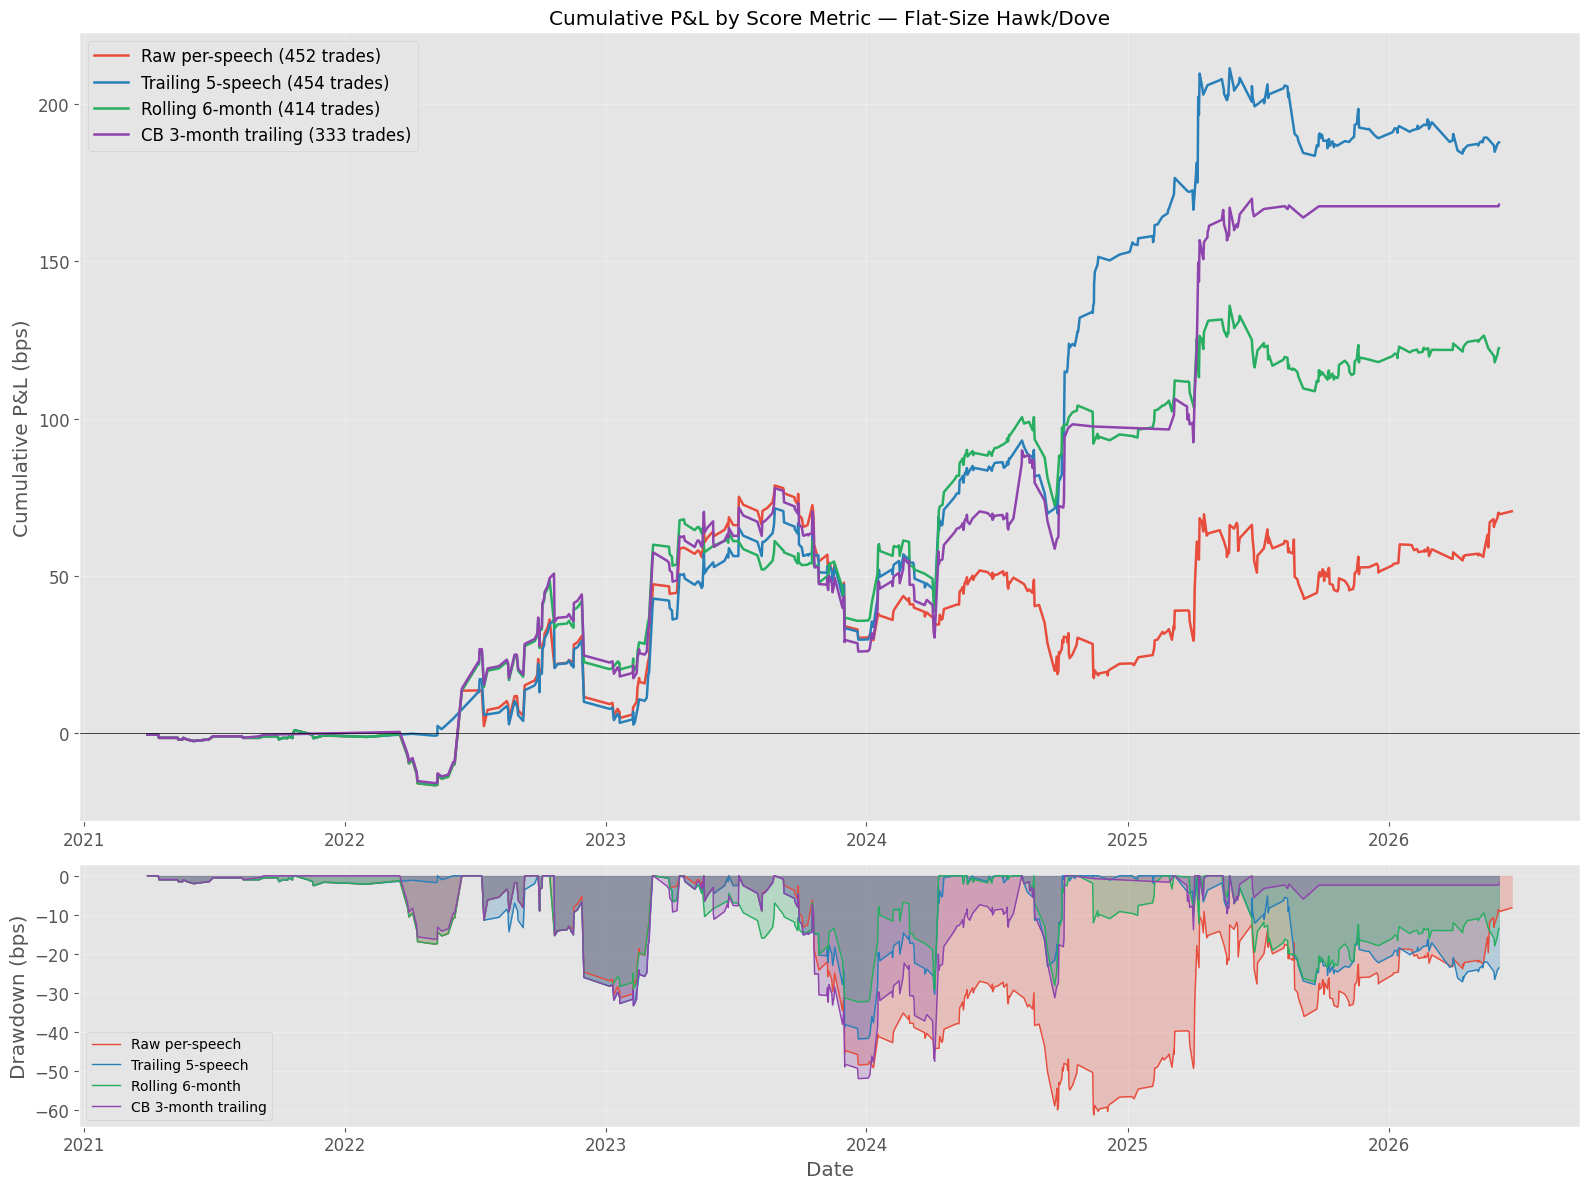

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})

# --- Panel 1: Cumulative bps ---
ax = axes[0]
for metric in SCORE_METRICS:
    cl = all_closed[metric]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=1.8, color=METRIC_COLORS[metric],
            label=f"{METRIC_LABELS[metric]} ({len(cl)} trades)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Cumulative P&L by Score Metric — Flat-Size Hawk/Dove")
ax.legend(loc="upper left", fontsize=12)
ax.grid(True, alpha=0.3)

# --- Panel 2: Drawdown ---
ax2 = axes[1]
for metric in SCORE_METRICS:
    cl = all_closed[metric]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.fill_between(cl["opened_at"].values, dd.values, 0,
                     alpha=0.25, color=METRIC_COLORS[metric])
    ax2.plot(cl["opened_at"].values, dd.values,
             lw=1, color=METRIC_COLORS[metric], label=METRIC_LABELS[metric])
ax2.set_ylabel("Drawdown (bps)")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary Comparison Table

In [6]:
rows = []
for metric in SCORE_METRICS:
    cl = all_closed[metric]
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    sr = (avg / std * np.sqrt(tpy)) if std > 0 else 0
    dd = (cl["cum_bps"] - cl["cum_bps"].cummax()).min()
    hawk_mask = cl["direction"] == 1
    rows.append({
        "Metric": METRIC_LABELS[metric],
        "Trades": n,
        "Hawk / Dove": f"{hawk_mask.sum()} / {(~hawk_mask).sum()}",
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": avg,
        "Med bps": cl["pnl_bps"].median(),
        "Std bps": std,
        "Hit Rate": cl["profitable"].mean(),
        "Sharpe": sr,
        "Max DD bps": dd,
        "Skew": cl["pnl_bps"].skew(),
        "Kurtosis": cl["pnl_bps"].kurtosis(),
    })

summary_df = pd.DataFrame(rows)
display(summary_df.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD bps": "{:.1f}", "Skew": "{:+.2f}", "Kurtosis": "{:.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Metric,Trades,Hawk / Dove,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD bps,Skew,Kurtosis
0,Raw per-speech,452,342 / 110,+70.5,+0.156,+0.077,3.55,54.9%,0.41,-61.2,+0.74,8.8
1,Trailing 5-speech,454,380 / 74,+187.8,+0.414,+0.156,3.82,57.5%,1.01,-41.8,+1.58,12.6
2,Rolling 6-month,414,317 / 97,+122.4,+0.296,+0.117,3.68,56.0%,0.72,-32.3,+1.37,10.8
3,CB 3-month trailing,333,310 / 23,+168.0,+0.504,+0.126,4.68,56.2%,0.86,-51.9,+1.72,8.8


## 6. Calendar-Year P&L Heatmap (bps)

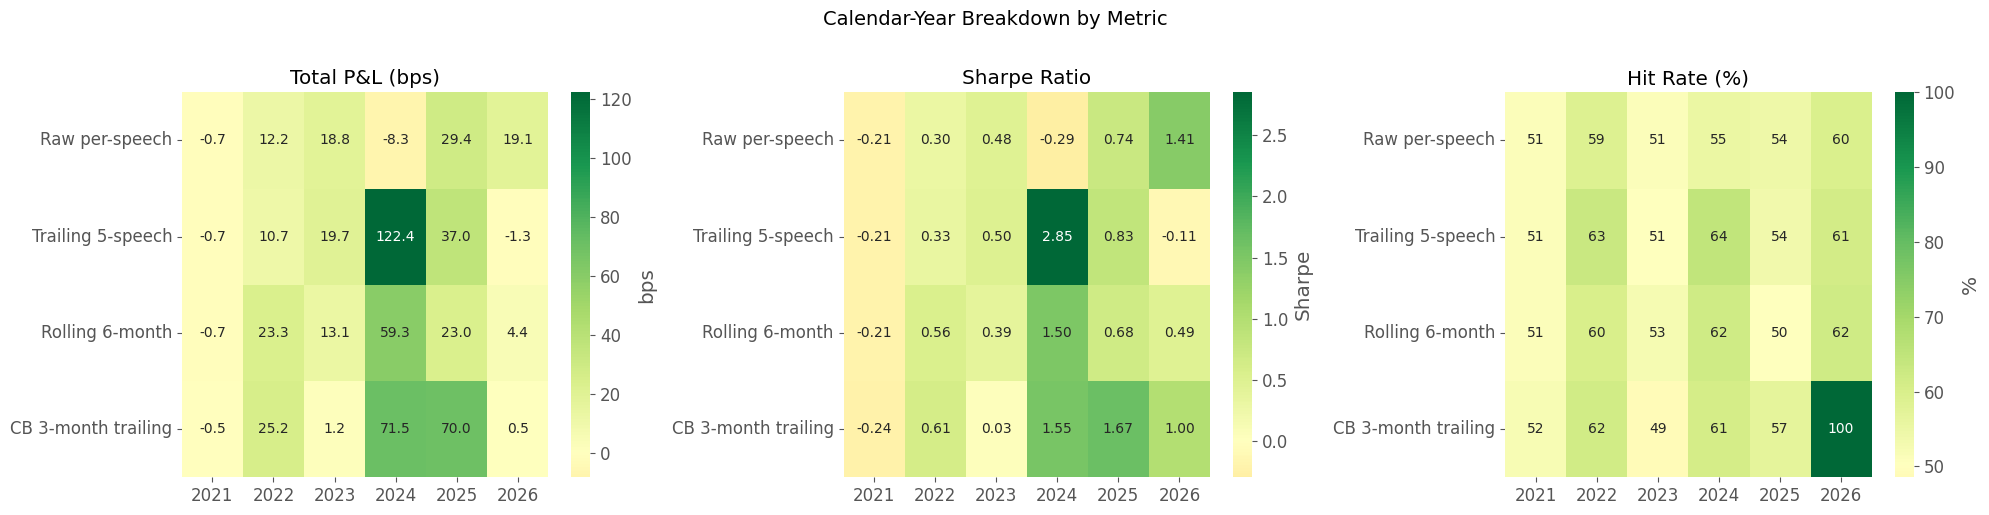

Trade counts per year:


,2021,2022,2023,2024,2025,2026
Raw per-speech,39,56,84,103,123,47
Trailing 5-speech,39,49,97,121,104,44
Rolling 6-month,39,60,74,95,109,37
CB 3-month trailing,23,60,103,94,51,2


In [7]:
all_years = sorted(set(y for cl in all_closed.values() for y in cl["year"].unique()))

# Build year-level stats for each metric
yr_bps = pd.DataFrame(index=[METRIC_LABELS[m] for m in SCORE_METRICS], columns=all_years, dtype=float)
yr_sr = yr_bps.copy()
yr_hit = yr_bps.copy()
yr_n = yr_bps.copy()

for metric in SCORE_METRICS:
    cl = all_closed[metric]
    for yr, grp in cl.groupby("year"):
        n = len(grp)
        avg = grp["pnl_bps"].mean()
        std = grp["pnl_bps"].std()
        yr_bps.loc[METRIC_LABELS[metric], yr] = grp["pnl_bps"].sum()
        yr_sr.loc[METRIC_LABELS[metric], yr] = (avg / std * np.sqrt(n)) if std > 0 else 0
        yr_hit.loc[METRIC_LABELS[metric], yr] = grp["profitable"].mean()
        yr_n.loc[METRIC_LABELS[metric], yr] = n

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(yr_bps.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            ax=axes[0], cbar_kws={"label": "bps"})
axes[0].set_title("Total P&L (bps)")

sns.heatmap(yr_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=axes[1], cbar_kws={"label": "Sharpe"})
axes[1].set_title("Sharpe Ratio")

sns.heatmap(yr_hit.astype(float) * 100, annot=True, fmt=".0f", cmap="RdYlGn",
            center=50, ax=axes[2], cbar_kws={"label": "%"})
axes[2].set_title("Hit Rate (%)")

for ax in axes:
    ax.set_ylabel("")

plt.suptitle("Calendar-Year Breakdown by Metric", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print trade counts
print("Trade counts per year:")
display(yr_n.astype(int))

## 7. Hawk vs Dove Breakdown

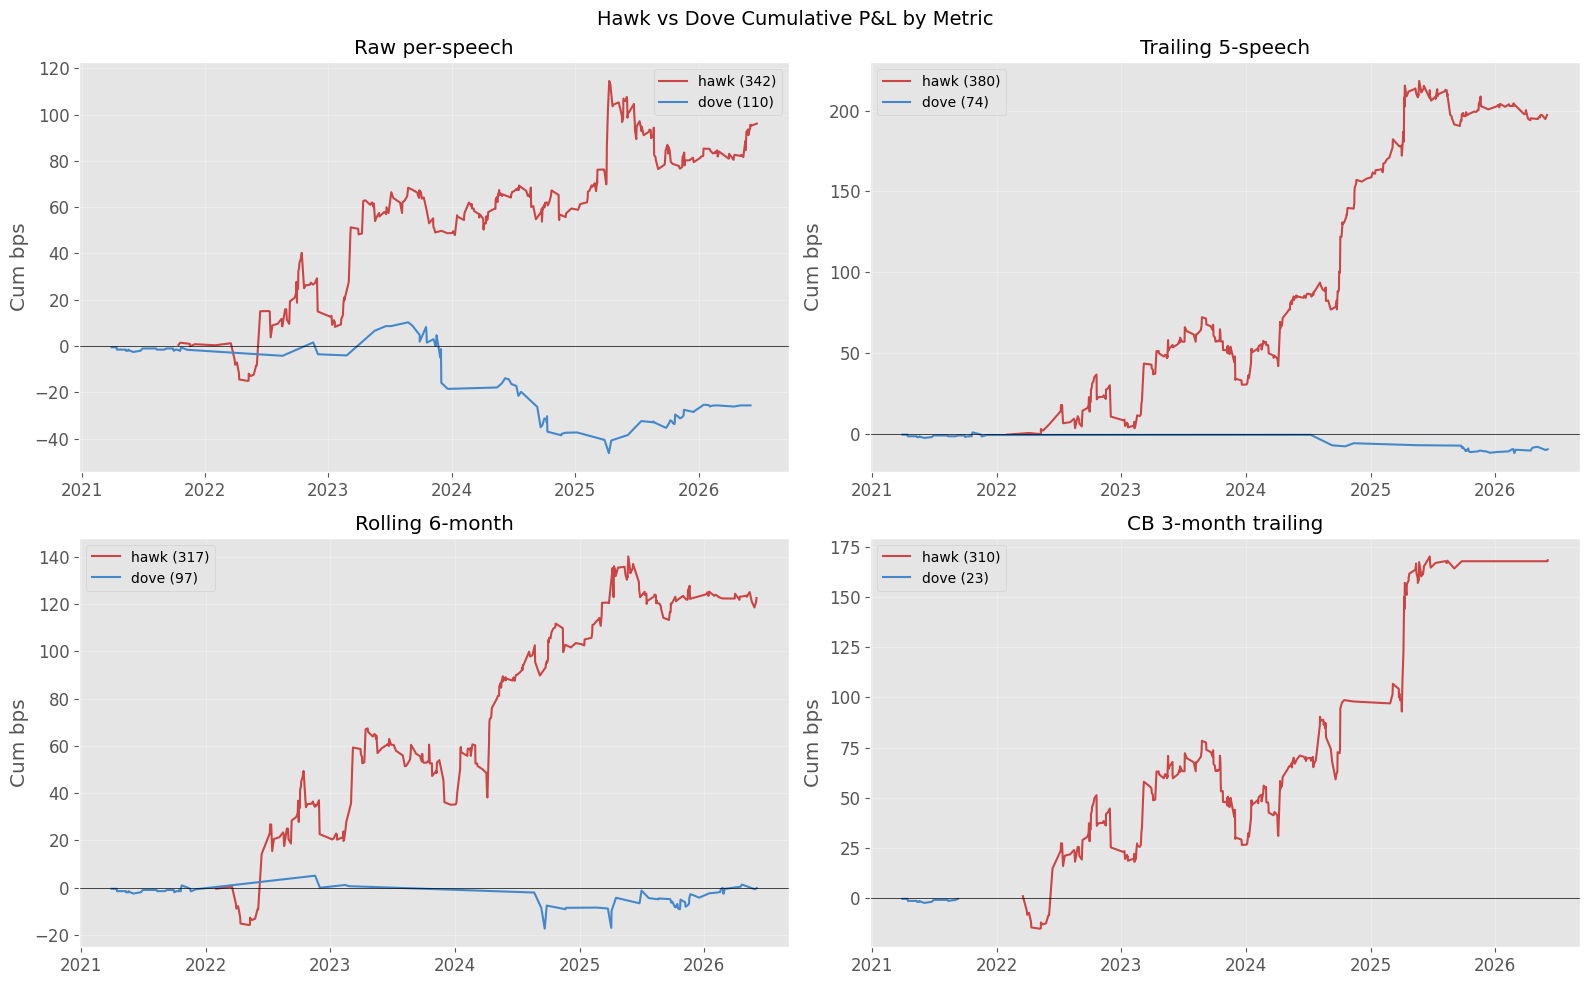

,Metric,Direction,Trades,Cum bps,Avg bps,Hit Rate
0,Raw per-speech,hawk,342,+96.1,+0.281,56.1%
1,Raw per-speech,dove,110,-25.6,-0.232,50.9%
2,Trailing 5-speech,hawk,380,+197.3,+0.519,58.4%
3,Trailing 5-speech,dove,74,-9.5,-0.129,52.7%
4,Rolling 6-month,hawk,317,+122.6,+0.387,57.1%
5,Rolling 6-month,dove,97,-0.2,-0.002,52.6%
6,CB 3-month trailing,hawk,310,+168.5,+0.543,56.5%
7,CB 3-month trailing,dove,23,-0.5,-0.022,52.2%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, metric in enumerate(SCORE_METRICS):
    ax = axes[idx // 2][idx % 2]
    cl = all_closed[metric]
    for label, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
        mask = cl["direction_label"] == label
        sub = cl[mask].sort_values("opened_at")
        if len(sub) == 0:
            continue
        ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
                lw=1.5, color=color, label=f"{label} ({mask.sum()})")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{METRIC_LABELS[metric]}")
    ax.set_ylabel("Cum bps")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Hawk vs Dove Cumulative P&L by Metric", fontsize=14)
plt.tight_layout()
plt.show()

# Table
dir_rows = []
for metric in SCORE_METRICS:
    cl = all_closed[metric]
    for d_label in ["hawk", "dove"]:
        sub = cl[cl["direction_label"] == d_label]
        if len(sub) == 0:
            continue
        dir_rows.append({
            "Metric": METRIC_LABELS[metric],
            "Direction": d_label,
            "Trades": len(sub),
            "Cum bps": sub["pnl_bps"].sum(),
            "Avg bps": sub["pnl_bps"].mean(),
            "Hit Rate": sub["profitable"].mean(),
        })
dir_df = pd.DataFrame(dir_rows)
display(dir_df.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Hit Rate": "{:.1%}",
}))

## 8. P&L Distributions

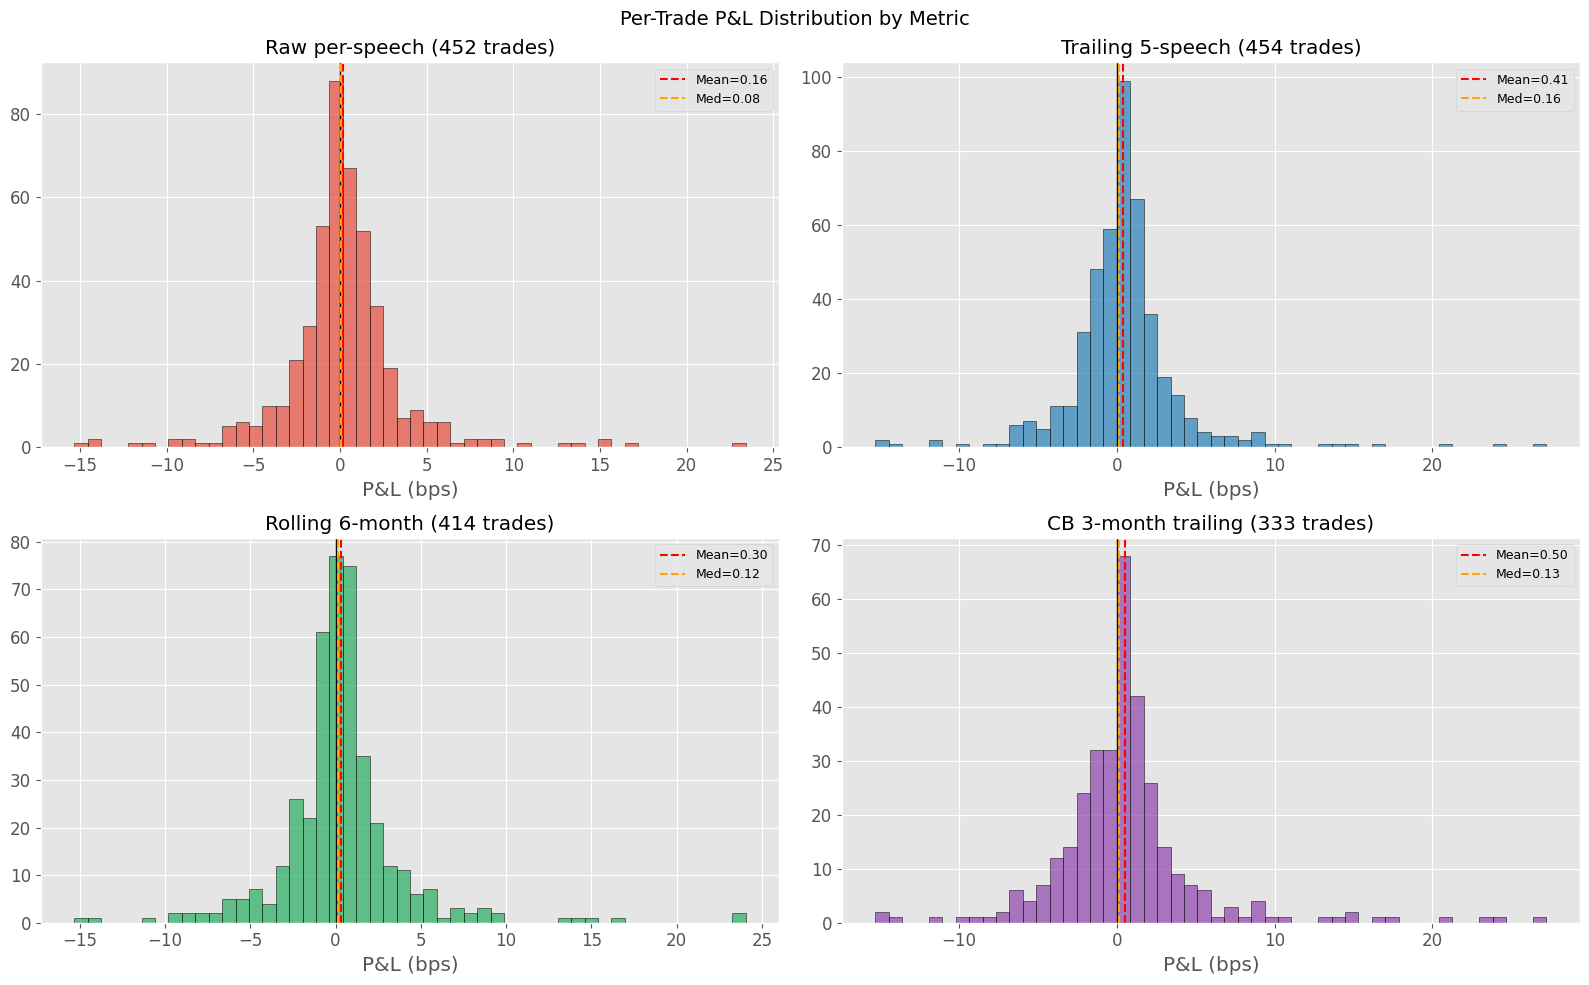

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, metric in enumerate(SCORE_METRICS):
    ax = axes[idx // 2][idx % 2]
    cl = all_closed[metric]
    ax.hist(cl["pnl_bps"], bins=50, alpha=0.7, color=METRIC_COLORS[metric], edgecolor="black")
    ax.axvline(0, color="k", lw=1)
    avg = cl["pnl_bps"].mean()
    med = cl["pnl_bps"].median()
    ax.axvline(avg, color="red", ls="--", lw=1.5, label=f"Mean={avg:.2f}")
    ax.axvline(med, color="orange", ls="--", lw=1.5, label=f"Med={med:.2f}")
    ax.set_title(f"{METRIC_LABELS[metric]} ({len(cl)} trades)")
    ax.set_xlabel("P&L (bps)")
    ax.legend(fontsize=9)

plt.suptitle("Per-Trade P&L Distribution by Metric", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Rolling 60-Trade Sharpe

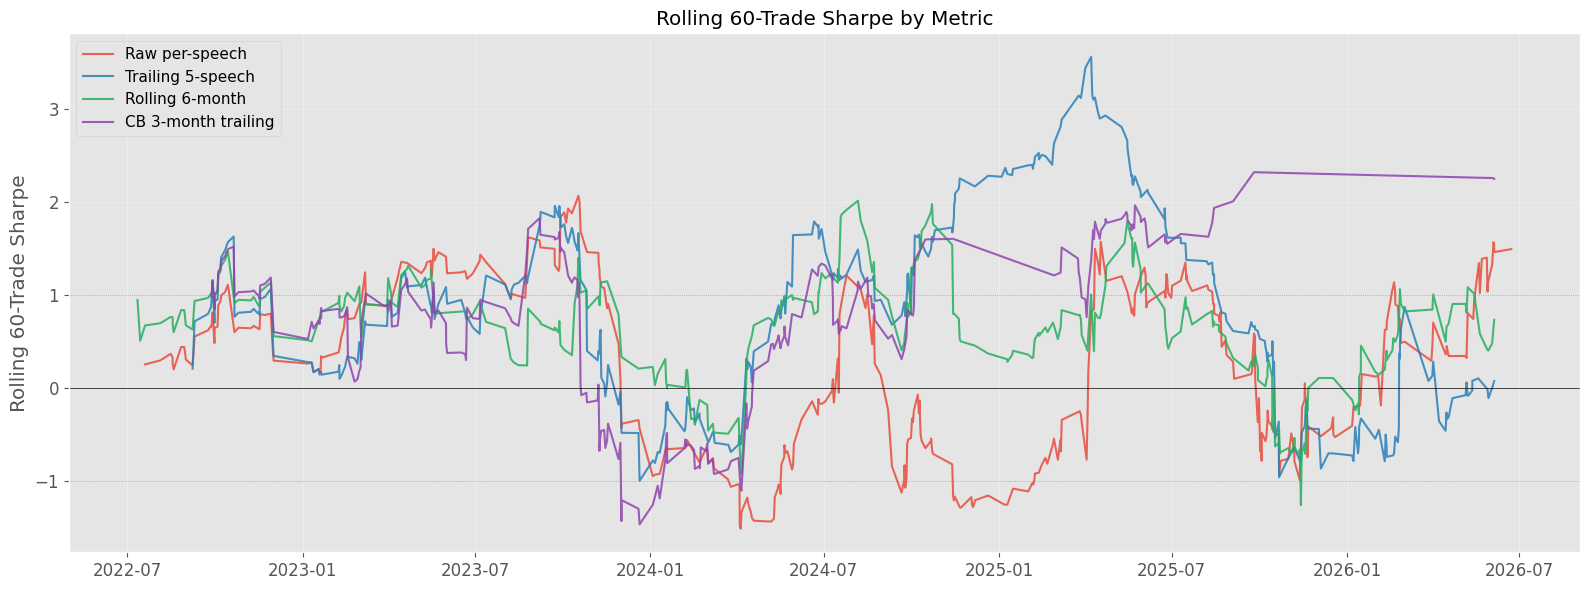

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
WINDOW = 60

for metric in SCORE_METRICS:
    cl = all_closed[metric].sort_values("opened_at")
    if len(cl) < WINDOW:
        continue
    roll_avg = cl["pnl_bps"].rolling(WINDOW).mean()
    roll_std = cl["pnl_bps"].rolling(WINDOW).std()
    roll_sr = (roll_avg / roll_std) * np.sqrt(WINDOW)
    ax.plot(cl["opened_at"].values, roll_sr.values,
            lw=1.5, color=METRIC_COLORS[metric],
            label=METRIC_LABELS[metric], alpha=0.85)

ax.axhline(0, color="k", lw=0.5)
ax.axhline(1, color="grey", lw=0.5, ls=":")
ax.axhline(-1, color="grey", lw=0.5, ls=":")
ax.set_ylabel(f"Rolling {WINDOW}-Trade Sharpe")
ax.set_title(f"Rolling {WINDOW}-Trade Sharpe by Metric")
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Speaker Attribution — Top/Bottom by Metric

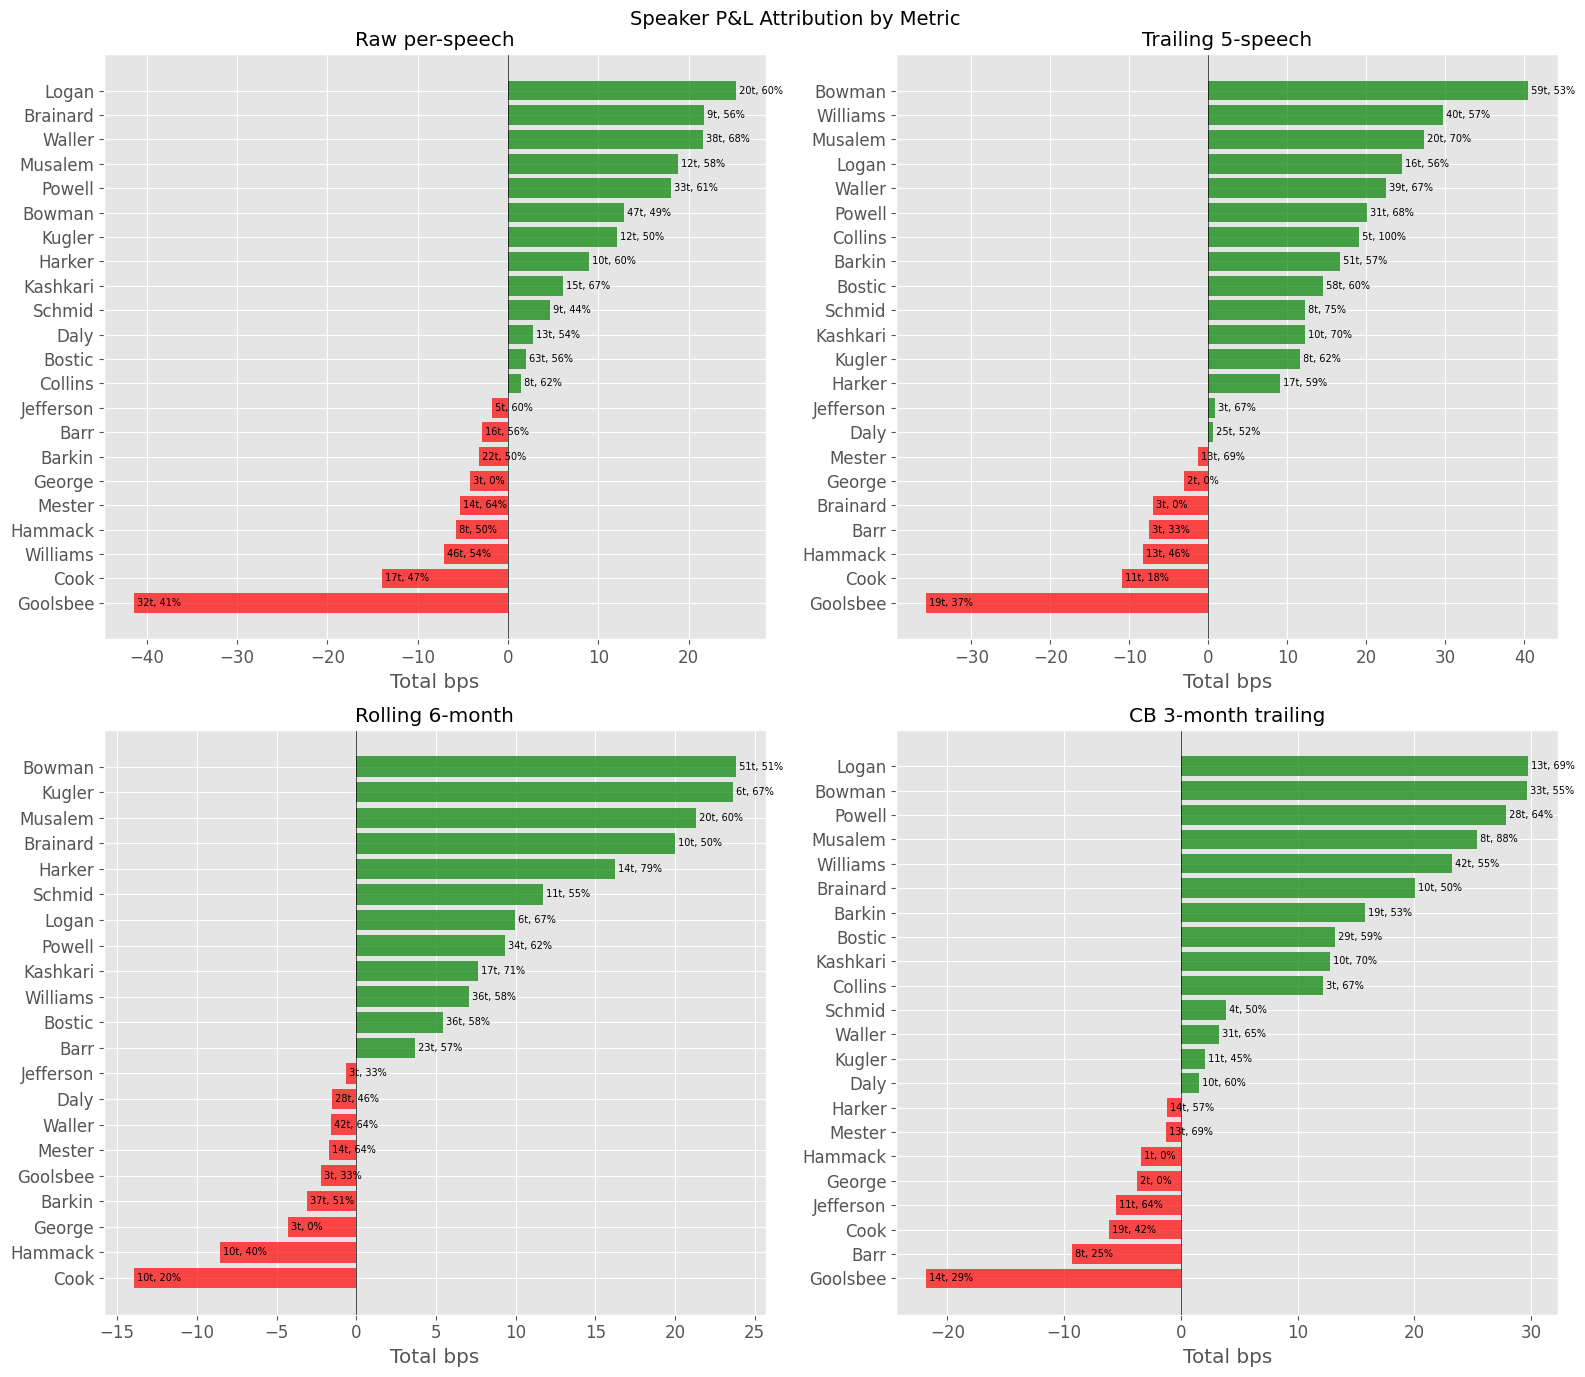

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for idx, metric in enumerate(SCORE_METRICS):
    ax = axes[idx // 2][idx % 2]
    cl = all_closed[metric]
    sp = cl.groupby("speaker").agg(
        total_bps=("pnl_bps", "sum"),
        trades=("pnl_bps", "count"),
        hit_rate=("profitable", "mean"),
    ).sort_values("total_bps", ascending=True)

    colors = ["green" if x > 0 else "red" for x in sp["total_bps"]]
    ax.barh(sp.index, sp["total_bps"], color=colors, alpha=0.7)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("Total bps")
    ax.set_title(f"{METRIC_LABELS[metric]}")
    for i, (speaker, row) in enumerate(sp.iterrows()):
        ax.text(row["total_bps"], i,
                f" {row['trades']:.0f}t, {row['hit_rate']:.0%}",
                va="center", fontsize=7)

plt.suptitle("Speaker P&L Attribution by Metric", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Year-over-Year Consistency

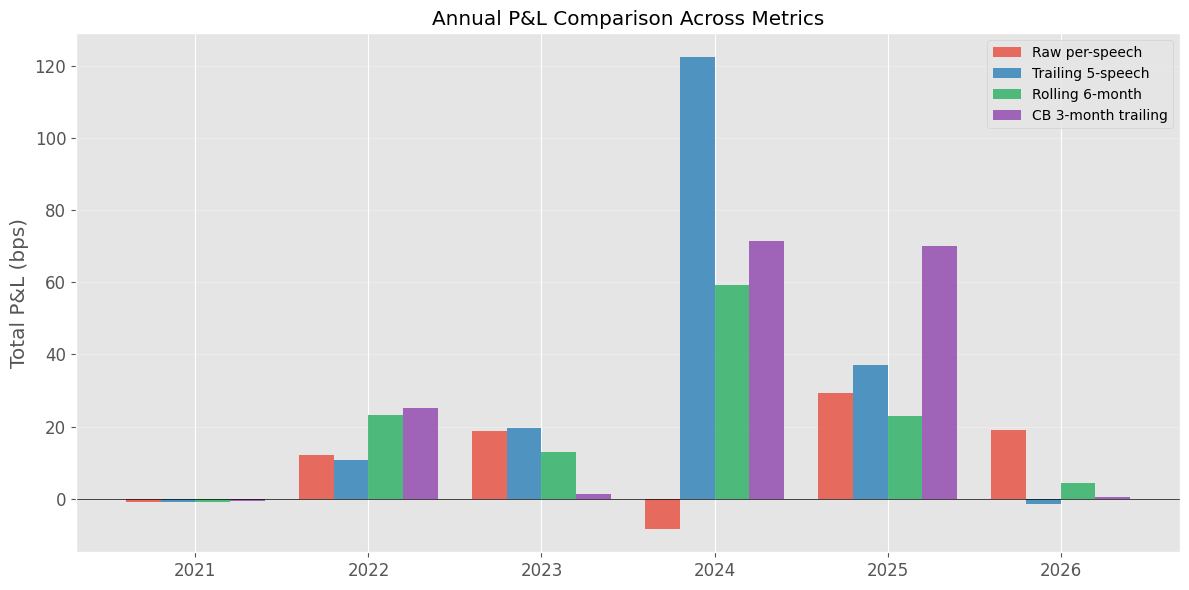

Fraction of positive years:
  Raw per-speech            4/6 (67%)
  Trailing 5-speech         4/6 (67%)
  Rolling 6-month           5/6 (83%)
  CB 3-month trailing       5/6 (83%)


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_years))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, metric in enumerate(SCORE_METRICS):
    vals = [yr_bps.loc[METRIC_LABELS[metric], yr] for yr in all_years]
    bars = ax.bar(x + offsets[i] * width, vals, width,
                  label=METRIC_LABELS[metric], color=METRIC_COLORS[metric], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(all_years)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Total P&L (bps)")
ax.set_title("Annual P&L Comparison Across Metrics")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Consistency metric: fraction of positive years
print("Fraction of positive years:")
for metric in SCORE_METRICS:
    vals = [yr_bps.loc[METRIC_LABELS[metric], yr] for yr in all_years]
    pos = sum(1 for v in vals if v > 0)
    print(f"  {METRIC_LABELS[metric]:25s} {pos}/{len(vals)} ({pos/len(vals):.0%})")

## 12. Trade Overlap Between Metrics

,Metric 1,Metric 2,Both agree,Conflict (opposite dir),Only Raw per-,Only Trailing,Only Rolling,Only CB 3-mon
0,Raw per-speech,Trailing 5-speech,264,39,193.0,196.0,NaN,NaN
1,Raw per-speech,Rolling 6-month,266,25,191.0,NaN,150.0,NaN
2,Raw per-speech,CB 3-month trailing,192,36,265.0,NaN,NaN,142.0
3,Trailing 5-speech,Rolling 6-month,323,3,NaN,137.0,93.0,NaN
4,Trailing 5-speech,CB 3-month trailing,255,4,NaN,205.0,NaN,79.0
5,Rolling 6-month,CB 3-month trailing,220,11,NaN,NaN,196.0,114.0



Jaccard similarity (shared trades / union):


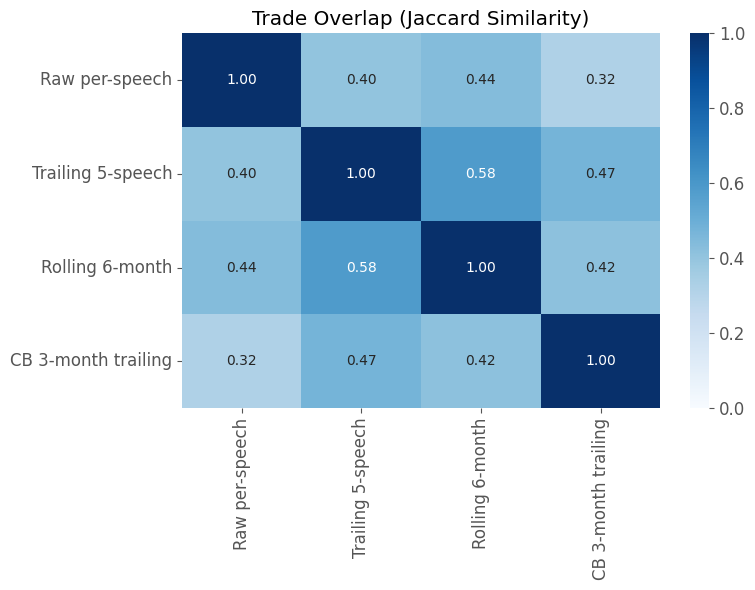

In [13]:
# How many trades share the same speech timestamp AND direction across metrics?
from itertools import combinations

# Build sets of (speech_date, speaker, direction) per metric
trade_keys = {}
for metric in SCORE_METRICS:
    evts = build_events(metric)
    trade_keys[metric] = set(
        (e["speech_ts"].strftime("%Y-%m-%d %H:%M"), e["speaker"], e["direction"])
        for e in evts
    )

# Pairwise overlap
overlap_rows = []
for m1, m2 in combinations(SCORE_METRICS, 2):
    common = trade_keys[m1] & trade_keys[m2]
    agree = len(common)
    only1 = len(trade_keys[m1] - trade_keys[m2])
    only2 = len(trade_keys[m2] - trade_keys[m1])
    # Trades in both but with OPPOSITE direction
    keys1 = {(ts, sp): d for ts, sp, d in trade_keys[m1]}
    keys2 = {(ts, sp): d for ts, sp, d in trade_keys[m2]}
    conflict = sum(1 for k in keys1 if k in keys2 and keys1[k] != keys2[k])
    overlap_rows.append({
        "Metric 1": METRIC_LABELS[m1],
        "Metric 2": METRIC_LABELS[m2],
        "Both agree": agree,
        "Conflict (opposite dir)": conflict,
        f"Only {METRIC_LABELS[m1][:8]}": only1,
        f"Only {METRIC_LABELS[m2][:8]}": only2,
    })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)

# Jaccard similarity matrix
print("\nJaccard similarity (shared trades / union):")
labels = [METRIC_LABELS[m] for m in SCORE_METRICS]
jac = pd.DataFrame(1.0, index=labels, columns=labels)
for m1, m2 in combinations(SCORE_METRICS, 2):
    intersection = len(trade_keys[m1] & trade_keys[m2])
    union = len(trade_keys[m1] | trade_keys[m2])
    j = intersection / union if union > 0 else 0
    jac.loc[METRIC_LABELS[m1], METRIC_LABELS[m2]] = j
    jac.loc[METRIC_LABELS[m2], METRIC_LABELS[m1]] = j

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(jac, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Trade Overlap (Jaccard Similarity)")
plt.tight_layout()
plt.show()